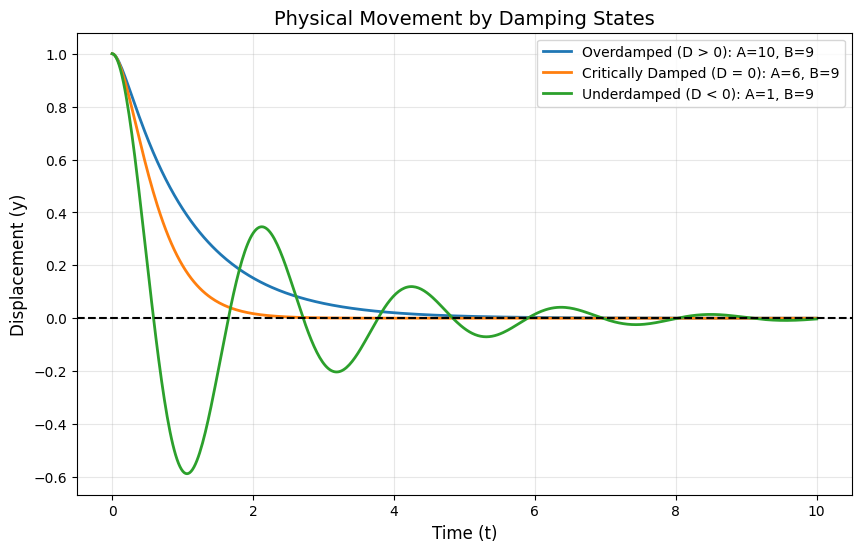

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_damping(A, B, t_max=10, y0=1, v0=0):
    """
    y'' + Ay' + By = 0 시스템을 시뮬레이션합니다.
    A: Damping coefficient (저항)
    B: Stiffness (복원력)
    """
    t = np.linspace(0, t_max, 500)
    D = A**2 - 4*B  # 판별식
    
    # 1. Overdamped (D > 0)
    if D > 0:
        r1 = (-A + np.sqrt(D)) / 2
        r2 = (-A - np.sqrt(D)) / 2
        # 초기조건 y(0)=y0, y'(0)=v0를 이용한 C1, C2 계산
        C2 = (v0 - r1*y0) / (r2 - r1)
        C1 = y0 - C2
        y = C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t)
        label = f'Overdamped (D > 0): A={A}, B={B}'

    # 2. Critically Damped (D = 0)
    elif D == 0:
        alpha = A / 2
        C1 = y0
        C2 = v0 + alpha * y0
        y = (C1 + C2 * t) * np.exp(-alpha * t)
        label = f'Critically Damped (D = 0): A={A}, B={B}'

    # 3. Underdamped (D < 0)
    else:
        alpha = -A / 2
        beta = np.sqrt(abs(D)) / 2
        K1 = y0
        K2 = (v0 - alpha * y0) / beta
        y = np.exp(alpha * t) * (K1 * np.cos(beta * t) + K2 * np.sin(beta * t))
        label = f'Underdamped (D < 0): A={A}, B={B}'
        
    return t, y, label

# 시각화 설정
plt.figure(figsize=(10, 6))

# 테스트 케이스 (B는 9로 고정, A를 변화시킴)
# B=9이면 Critically Damped를 위한 A는 sqrt(4*9) = 6
cases = [
    (10, 9), # Overdamped (A^2 = 100 > 36)
    (6, 9),  # Critically Damped (A^2 = 36 = 36)
    (1, 9)   # Underdamped (A^2 = 1 < 36)
]

for A, B in cases:
    t, y, label = simulate_damping(A, B)
    plt.plot(t, y, label=label, linewidth=2)

plt.axhline(0, color='black', linestyle='--')
plt.title("Physical Movement by Damping States", fontsize=14)
plt.xlabel("Time (t)", fontsize=12)
plt.ylabel("Displacement (y)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()